**1. Load Student Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    "Attendance": [65, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 95],
    "Previous_Score": [45, 50, 55, 60, 62, 65, 70, 73, 78, 82, 85, 88],
    "Final_Score": [50, 55, 60, 65, 68, 72, 76, 80, 85, 89, 93, 96]
}

df = pd.DataFrame(data)

print("Student Dataset:")
print(df)

Student Dataset:
    Study_Hours  Attendance  Previous_Score  Final_Score
0             2          65              45           50
1             3          70              50           55
2             4          72              55           60
3             5          75              60           65
4             6          78              62           68
5             7          80              65           72
6             8          82              70           76
7             9          85              73           80
8            10          88              78           85
9            11          90              82           89
10           12          92              85           93
11           13          95              88           96


**2. Linear Regression**

In [9]:
X = df[["Study_Hours", "Attendance", "Previous_Score"]]
y = df["Final_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression
MAE: 0.3812600969305227
MSE: 0.21124414676471748
RMSE: 0.4596130402465943
R2 Score: 0.9994385123092491


**3. Ridge Regression**

In [3]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_predictions)
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression")
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("R2 Score:", ridge_r2)

Ridge Regression
MAE: 0.9600714464401984
MSE: 1.073700669750292
RMSE: 1.0361952855279222
R2 Score: 0.9971460998146034


**4.Polynomial Regression**

In [4]:
polynomial_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

polynomial_model.fit(X_train, y_train)

polynomial_predictions = polynomial_model.predict(X_test)

polynomial_mae = mean_absolute_error(y_test, polynomial_predictions)
polynomial_mse = mean_squared_error(y_test, polynomial_predictions)
polynomial_rmse = np.sqrt(polynomial_mse)
polynomial_r2 = r2_score(y_test, polynomial_predictions)

print("Polynomial Regression")
print("MAE:", polynomial_mae)
print("MSE:", polynomial_mse)
print("RMSE:", polynomial_rmse)
print("R2 Score:", polynomial_r2)

Polynomial Regression
MAE: 2.7639159223274796
MSE: 14.113652471810854
RMSE: 3.7568141385768414
R2 Score: 0.9624858617110758


**5.Gradient Descent**

In [5]:
class GradientDescentLinearRegression:

    def __init__(self, learning_rate=0.03, epochs=5000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):

            predictions = X @ self.weights + self.bias

            error = predictions - y

            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            loss = np.mean(error ** 2)

            self.loss_history.append(loss)

        return self

    def predict(self, X):
        return X @ self.weights + self.bias


scaler_gd = StandardScaler()

X_train_scaled = scaler_gd.fit_transform(X_train)
X_test_scaled = scaler_gd.transform(X_test)

gd_model = GradientDescentLinearRegression(
    learning_rate=0.03,
    epochs=5000
)

gd_model.fit(X_train_scaled, y_train.to_numpy())

gd_predictions = gd_model.predict(X_test_scaled)

gd_mae = mean_absolute_error(y_test, gd_predictions)
gd_mse = mean_squared_error(y_test, gd_predictions)
gd_rmse = np.sqrt(gd_mse)
gd_r2 = r2_score(y_test, gd_predictions)

print("Gradient Descent")
print("MAE:", gd_mae)
print("MSE:", gd_mse)
print("RMSE:", gd_rmse)
print("R2 Score:", gd_r2)

print("Initial MSE:", gd_model.loss_history[0])
print("Final MSE:", gd_model.loss_history[-1])

Gradient Descent
MAE: 0.3700484339815328
MSE: 0.18555707693259718
RMSE: 0.43076336535573356
R2 Score: 0.999506788631898
Initial MSE: 5475.0
Final MSE: 0.04890250315930869


**6.Convergence**

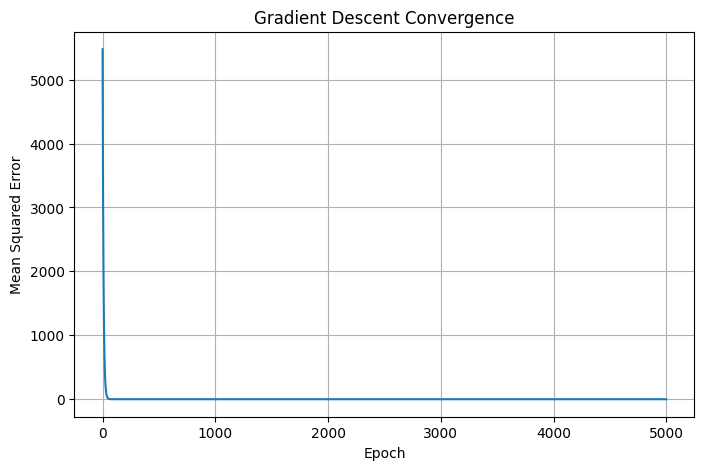

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(gd_model.loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Convergence")

plt.grid(True)

plt.show()

**7.Model Comparison**

In [7]:
results = [
    [
        "Linear Regression",
        linear_mae,
        linear_mse,
        linear_rmse,
        linear_r2
    ],
    [
        "Ridge Regression",
        ridge_mae,
        ridge_mse,
        ridge_rmse,
        ridge_r2
    ],
    [
        "Polynomial Regression",
        polynomial_mae,
        polynomial_mse,
        polynomial_rmse,
        polynomial_r2
    ],
    [
        "Gradient Descent",
        gd_mae,
        gd_mse,
        gd_rmse,
        gd_r2
    ]
]

final_results = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

print("Final Model Comparison")
print(final_results)

Final Model Comparison
                   Model       MAE        MSE      RMSE  R2 Score
0      Linear Regression  0.381260   0.211244  0.459613  0.999439
1       Ridge Regression  0.960071   1.073701  1.036195  0.997146
2  Polynomial Regression  2.763916  14.113652  3.756814  0.962486
3       Gradient Descent  0.370048   0.185557  0.430763  0.999507
